In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

In [5]:
DATA_DIR = "/kaggle/input/datasets/duydang2/mcvsld-split"
BATCH_SIZE = 64
IMAGE_SIZE = 224
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
NUM_WORKERS = 2
SAVE_DIR = Path("experiments/resnet18_scratch_notebook")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [7]:
train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

CLASS_NAMES = train_dataset.classes
CLASS_TO_IDX = train_dataset.class_to_idx
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Class to index:", CLASS_TO_IDX)
print("Num classes:", NUM_CLASSES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['Chickenpox', 'Cowpox', 'HFMD', 'Healthy', 'Measles', 'Monkeypox']
Class to index: {'Chickenpox': 0, 'Cowpox': 1, 'HFMD': 2, 'Healthy': 3, 'Measles': 4, 'Monkeypox': 5}
Num classes: 6
Train samples: 7246
Val samples: 904
Test samples: 910


In [8]:
# Xem số lượng ảnh mỗi lớp
def count_per_class(dataset):
    counts = {}
    for _, label in dataset.samples:
        class_name = dataset.classes[label]
        counts[class_name] = counts.get(class_name, 0) + 1
    return counts

train_counts = count_per_class(train_dataset)
val_counts = count_per_class(val_dataset)
test_counts = count_per_class(test_dataset)

stats_df = pd.DataFrame({
    "train": pd.Series(train_counts),
    "val": pd.Series(val_counts),
    "test": pd.Series(test_counts),
}).fillna(0).astype(int)

stats_df

,train,val,test
Chickenpox,720,90,90
Cowpox,633,79,80
HFMD,1545,193,194
Healthy,1094,136,138
Measles,528,66,66
Monkeypox,2726,340,342


In [9]:
# =========================
# MODEL: RESNET18 FROM SCRATCH
# =========================

model = models.resnet18(weights=None)  # from scratch, không dùng pretrained

# Lấy số input features của fully connected layer cuối
in_features = model.fc.in_features

# Thay layer cuối cho phù hợp số class của dataset
model.fc = nn.Linear(in_features, NUM_CLASSES)

# Đưa model lên GPU/CPU
model = model.to(DEVICE)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [10]:
# =========================
# HELPER FUNCTIONS
# =========================
def format_epoch_time(seconds: float) -> str:
    minutes = int(seconds // 60)
    secs = seconds % 60
    if minutes > 0:
        return f"{minutes}m {secs:.0f}s"
    return f"{secs:.0f}s"


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total if total > 0 else 0.0
    epoch_acc = correct / total if total > 0 else 0.0

    return epoch_loss, epoch_acc


def compute_specificity_multiclass(conf_matrix):
    specificities = []

    for i in range(conf_matrix.shape[0]):
        tp = conf_matrix[i, i]
        fn = conf_matrix[i, :].sum() - tp
        fp = conf_matrix[:, i].sum() - tp
        tn = conf_matrix.sum() - (tp + fn + fp)

        specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(specificity_i)

    return float(np.mean(specificities)), specificities


def evaluate_model(model, loader, criterion, device, num_classes):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            total_samples += batch_size

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    avg_loss = running_loss / total_samples if total_samples > 0 else 0.0

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    sensitivity = recall
    mcc = matthews_corrcoef(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    specificity_macro, specificity_per_class = compute_specificity_multiclass(cm)

    try:
        y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
        roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        roc_auc = None

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "roc_auc_macro_ovr": roc_auc,
        "sensitivity_macro": sensitivity,
        "specificity_macro": specificity_macro,
        "specificity_per_class": specificity_per_class,
        "mcc": mcc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

    return metrics


def print_metrics(metrics, class_names=None, split_name="Evaluation"):
    print(f"\n===== {split_name} Metrics =====")
    print(f"Loss         : {metrics['loss']:.4f}")
    print(f"Accuracy     : {metrics['accuracy']:.4f}")
    print(f"Precision    : {metrics['precision_macro']:.4f}")
    print(f"Recall       : {metrics['recall_macro']:.4f}")
    print(f"F1-score     : {metrics['f1_macro']:.4f}")

    if metrics["roc_auc_macro_ovr"] is not None:
        print(f"ROC-AUC      : {metrics['roc_auc_macro_ovr']:.4f}")
    else:
        print("ROC-AUC      : Không tính được")

    print(f"Sensitivity  : {metrics['sensitivity_macro']:.4f}")
    print(f"Specificity  : {metrics['specificity_macro']:.4f}")
    print(f"MCC          : {metrics['mcc']:.4f}")

    print("\nConfusion Matrix:")
    print(metrics["confusion_matrix"])

    if class_names is not None:
        print("\nClassification Report:")
        print(
            classification_report(
                metrics["y_true"],
                metrics["y_pred"],
                target_names=class_names,
                digits=4,
                zero_division=0
            )
        )


def plot_confusion_matrix(metrics, class_names, title="Confusion Matrix"):
    cm = metrics["confusion_matrix"]
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [11]:
# =========================
# TRAIN LOOP
# =========================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_precision": [],
    "val_recall": [],
    "val_mcc": [],
}

best_val_acc = 0.0
best_model_path = SAVE_DIR / "best_vgg16_scratch_notebook.pth"

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_metrics = evaluate_model(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        num_classes=NUM_CLASSES
    )

    epoch_time = time.time() - epoch_start_time
    epoch_time_str = format_epoch_time(epoch_time)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_f1"].append(val_metrics["f1_macro"])
    history["val_precision"].append(val_metrics["precision_macro"])
    history["val_recall"].append(val_metrics["recall_macro"])
    history["val_mcc"].append(val_metrics["mcc"])

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(
        f"{epoch_time_str} - "
        f"accuracy: {train_acc:.4f} - "
        f"loss: {train_loss:.4f} - "
        f"val_accuracy: {val_metrics['accuracy']:.4f} - "
        f"val_loss: {val_metrics['loss']:.4f}"
    )
    print("Confusion Matrix (Validation):")
    print(val_metrics["confusion_matrix"])
    print("-" * 70)

    if val_metrics["accuracy"] > best_val_acc:
        best_val_acc = val_metrics["accuracy"]
        torch.save(model.state_dict(), best_model_path)

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
print(f"Best model saved at: {best_model_path}")

Epoch 1/30
29s - accuracy: 0.4963 - loss: 1.3285 - val_accuracy: 0.5619 - val_loss: 1.1771
Confusion Matrix (Validation):
[[  7   0  11   7   0  65]
 [  1  23  23   2   2  28]
 [  0   7 144  17   0  25]
 [  3   2  20  87   0  24]
 [  2   0  21  11   5  27]
 [ 13   6  42  32   5 242]]
----------------------------------------------------------------------
Epoch 2/30
24s - accuracy: 0.5958 - loss: 1.0668 - val_accuracy: 0.6361 - val_loss: 0.9729
Confusion Matrix (Validation):
[[ 40   4   4   9   0  33]
 [  7  50   6   1   1  14]
 [  5   6 139  21   0  22]
 [  2   2   7  98   0  27]
 [ 14   0  11  14   8  19]
 [ 38  20  16  23   3 240]]
----------------------------------------------------------------------
Epoch 3/30
24s - accuracy: 0.6478 - loss: 0.9223 - val_accuracy: 0.6195 - val_loss: 1.0666
Confusion Matrix (Validation):
[[ 22   8  10  16  12  22]
 [  0  62   8   1   1   7]
 [  1  22 141  13   2  14]
 [  0   1  12 113   2   8]
 [  1   9   9  23  16   8]
 [ 20  34  29  33  18 206]]
---

In [12]:
# Lịch sử train
history_df = pd.DataFrame(history)
history_df

,train_loss,train_acc,val_loss,val_acc,val_f1,val_precision,val_recall,val_mcc
0,1.328535,0.496274,1.177144,0.561947,0.419464,0.498231,0.423710,0.410316
1,1.066774,0.595777,0.972911,0.636062,0.552238,0.613294,0.557541,0.523588
2,0.922323,0.647806,1.066584,0.619469,0.539286,0.548241,0.573169,0.521651
3,0.799045,0.700248,1.100578,0.673673,0.591670,0.648264,0.599041,0.582727
4,0.686338,0.743445,0.684774,0.751106,0.690466,0.764913,0.653872,0.670333
5,0.574682,0.789125,0.702215,0.755531,0.729780,0.783447,0.696924,0.678774
6,0.501716,0.818245,0.626598,0.777655,0.746627,0.759239,0.754871,0.711575
7,0.429515,0.842948,1.009981,0.647124,0.643232,0.727292,0.653436,0.584728
8,0.379997,0.865029,0.429517,0.856195,0.838658,0.858088,0.832694,0.813598
9,0.309086,0.891388,0.434087,0.855088,0.837132,0.845339,0.836254,0.811499


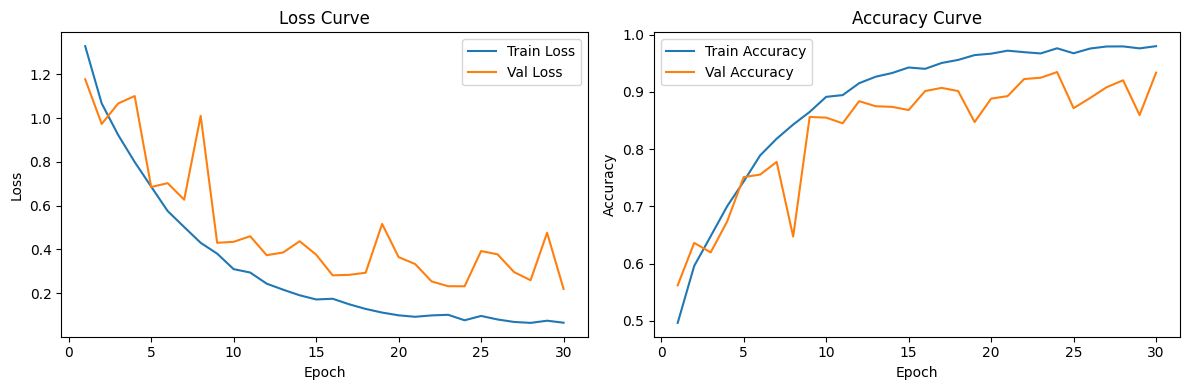

In [13]:
# Vẽ loss và accuracy
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# =========================
# LOAD BEST MODEL & TEST
# =========================
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_metrics = evaluate_model(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    num_classes=NUM_CLASSES
)

print_metrics(test_metrics, class_names=CLASS_NAMES, split_name="Test")


===== Test Metrics =====
Loss         : 0.2369
Accuracy     : 0.9374
Precision    : 0.9473
Recall       : 0.9168
F1-score     : 0.9305
ROC-AUC      : 0.9930
Sensitivity  : 0.9168
Specificity  : 0.9856
MCC          : 0.9184

Confusion Matrix:
[[ 78   0   1   1   1   9]
 [  1  72   1   0   0   6]
 [  0   1 191   0   0   2]
 [  0   1  10 120   1   6]
 [  0   0   3   1  60   2]
 [  4   0   5   0   1 332]]

Classification Report:
              precision    recall  f1-score   support

  Chickenpox     0.9398    0.8667    0.9017        90
      Cowpox     0.9730    0.9000    0.9351        80
        HFMD     0.9052    0.9845    0.9432       194
     Healthy     0.9836    0.8696    0.9231       138
     Measles     0.9524    0.9091    0.9302        66
   Monkeypox     0.9300    0.9708    0.9499       342

    accuracy                         0.9374       910
   macro avg     0.9473    0.9168    0.9305       910
weighted avg     0.9392    0.9374    0.9369       910



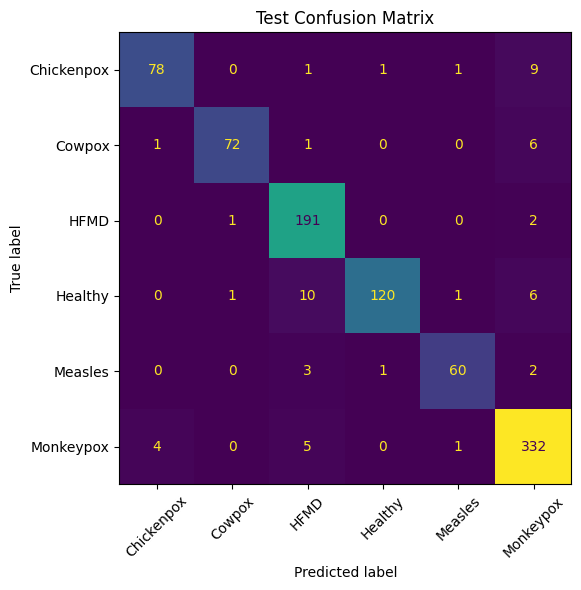

In [15]:
# Vẽ confusion matrix cho test
plot_confusion_matrix(test_metrics, CLASS_NAMES, title="Test Confusion Matrix")

In [16]:
# Lưu metrics test ra file CSV
test_summary = pd.DataFrame([{
    "loss": test_metrics["loss"],
    "accuracy": test_metrics["accuracy"],
    "precision_macro": test_metrics["precision_macro"],
    "recall_macro": test_metrics["recall_macro"],
    "f1_macro": test_metrics["f1_macro"],
    "roc_auc_macro_ovr": test_metrics["roc_auc_macro_ovr"],
    "sensitivity_macro": test_metrics["sensitivity_macro"],
    "specificity_macro": test_metrics["specificity_macro"],
    "mcc": test_metrics["mcc"],
}])

test_summary_path = SAVE_DIR / "test_metrics.csv"
test_summary.to_csv(test_summary_path, index=False)
print("Saved:", test_summary_path)
test_summary

Saved: experiments/resnet18_scratch_notebook/test_metrics.csv


,loss,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro_ovr,sensitivity_macro,specificity_macro,mcc
0,0.236931,0.937363,0.947317,0.91677,0.930541,0.99297,0.91677,0.985567,0.918419
